In [2]:
print("Hello! Skin Disease AI project started.")

Hello! Skin Disease AI project started.


In [3]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]

Python executable:
C:\ProgramData\anaconda3\python.exe


In [4]:
try:
    import tensorflow as tf
    print("TensorFlow version:", tf.__version__)
except ModuleNotFoundError:
    print("TensorFlow is not installed in this Jupyter environment.")

TensorFlow version: 2.21.0


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("All libraries are working!")

NumPy version: 2.2.4
Pandas version: 2.2.3
All libraries are working!


In [6]:
from PIL import Image

print("Pillow is working!")

Pillow is working!


In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("Environment is ready!")

Environment is ready!


In [8]:
import os

train_path = "dataset/SkinDisease/train"
test_path = "dataset/SkinDisease/test"

print("Train folder exists:", os.path.exists(train_path))
print("Test folder exists:", os.path.exists(test_path))

Train folder exists: True
Test folder exists: True


In [9]:
# Get all disease class names
classes = sorted([
    folder for folder in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, folder))
])

print("Number of classes:", len(classes))
print("\nDisease classes:")

for i, disease in enumerate(classes, start=1):
    print(f"{i}. {disease}")

Number of classes: 22

Disease classes:
1. Acne
2. Actinic_Keratosis
3. Benign_tumors
4. Bullous
5. Candidiasis
6. DrugEruption
7. Eczema
8. Infestations_Bites
9. Lichen
10. Lupus
11. Moles
12. Psoriasis
13. Rosacea
14. Seborrh_Keratoses
15. SkinCancer
16. Sun_Sunlight_Damage
17. Tinea
18. Unknown_Normal
19. Vascular_Tumors
20. Vasculitis
21. Vitiligo
22. Warts


In [10]:
import os

print(os.getcwd())

C:\Users\Riya Keswani\Downloads\SkinDiseaseAI


In [11]:
import os

print(f"{'Disease':<25} {'Train':>10} {'Test':>10}")
print("-" * 50)

total_train = 0
total_test = 0

for disease in classes:
    train_class_path = os.path.join(train_path, disease)
    test_class_path = os.path.join(test_path, disease)
    
    train_count = len([
        f for f in os.listdir(train_class_path)
        if os.path.isfile(os.path.join(train_class_path, f))
    ])
    
    test_count = len([
        f for f in os.listdir(test_class_path)
        if os.path.isfile(os.path.join(test_class_path, f))
    ])
    
    total_train += train_count
    total_test += test_count
    
    print(f"{disease:<25} {train_count:>10} {test_count:>10}")

print("-" * 50)
print(f"{'TOTAL':<25} {total_train:>10} {total_test:>10}")

Disease                        Train       Test
--------------------------------------------------
Acne                             593         65
Actinic_Keratosis                748         83
Benign_tumors                   1093        121
Bullous                          504         55
Candidiasis                      248         27
DrugEruption                     547         61
Eczema                          1010        112
Infestations_Bites               524         60
Lichen                           553         61
Lupus                            311         34
Moles                            361         40
Psoriasis                        820         88
Rosacea                          254         28
Seborrh_Keratoses                455         51
SkinCancer                       693         77
Sun_Sunlight_Damage              312         34
Tinea                            923        102
Unknown_Normal                  1651        189
Vascular_Tumors                  543 

In [12]:
from PIL import Image
import os
import random

corrupted_files = []
checked_images = 0

for split_path in [train_path, test_path]:
    for disease in os.listdir(split_path):
        disease_path = os.path.join(split_path, disease)

        if not os.path.isdir(disease_path):
            continue

        files = [
            f for f in os.listdir(disease_path)
            if os.path.isfile(os.path.join(disease_path, f))
        ]

        # Check up to 20 random images from each class
        sample_files = random.sample(files, min(20, len(files)))

        for filename in sample_files:
            file_path = os.path.join(disease_path, filename)

            try:
                with Image.open(file_path) as img:
                    img.verify()
                checked_images += 1
            except Exception:
                corrupted_files.append(file_path)

print("Images checked:", checked_images)
print("Corrupted images found:", len(corrupted_files))

if corrupted_files:
    print("\nCorrupted files:")
    for file in corrupted_files:
        print(file)

Images checked: 880
Corrupted images found: 0


In [13]:
from PIL import Image
import os
import random

image_sizes = []

# Take random images from training data
for disease in os.listdir(train_path):
    disease_path = os.path.join(train_path, disease)

    if not os.path.isdir(disease_path):
        continue

    files = [
        f for f in os.listdir(disease_path)
        if os.path.isfile(os.path.join(disease_path, f))
    ]

    sample_files = random.sample(files, min(5, len(files)))

    for filename in sample_files:
        file_path = os.path.join(disease_path, filename)

        try:
            with Image.open(file_path) as img:
                image_sizes.append(img.size)
        except:
            pass

print("Number of images checked:", len(image_sizes))
print("First 20 image sizes:")
print(image_sizes[:20])

Number of images checked: 110
First 20 image sizes:
[(720, 479), (294, 222), (294, 222), (473, 720), (294, 222), (260, 194), (487, 720), (480, 360), (472, 720), (720, 472), (720, 480), (480, 720), (720, 472), (720, 480), (480, 720), (272, 185), (258, 195), (720, 480), (720, 472), (243, 207)]


In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [15]:
#training images: data augmentation and help the model generalize better

In [16]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("ImageDataGenerators created successfully!")

ImageDataGenerators created successfully!


In [18]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 13898 images belonging to 22 classes.
Found 1546 images belonging to 22 classes.


In [19]:
print("Class indices:")
print(train_generator.class_indices)

Class indices:
{'Acne': 0, 'Actinic_Keratosis': 1, 'Benign_tumors': 2, 'Bullous': 3, 'Candidiasis': 4, 'DrugEruption': 5, 'Eczema': 6, 'Infestations_Bites': 7, 'Lichen': 8, 'Lupus': 9, 'Moles': 10, 'Psoriasis': 11, 'Rosacea': 12, 'Seborrh_Keratoses': 13, 'SkinCancer': 14, 'Sun_Sunlight_Damage': 15, 'Tinea': 16, 'Unknown_Normal': 17, 'Vascular_Tumors': 18, 'Vasculitis': 19, 'Vitiligo': 20, 'Warts': 21}


In [20]:
#Visualize a batch of preprocessed images

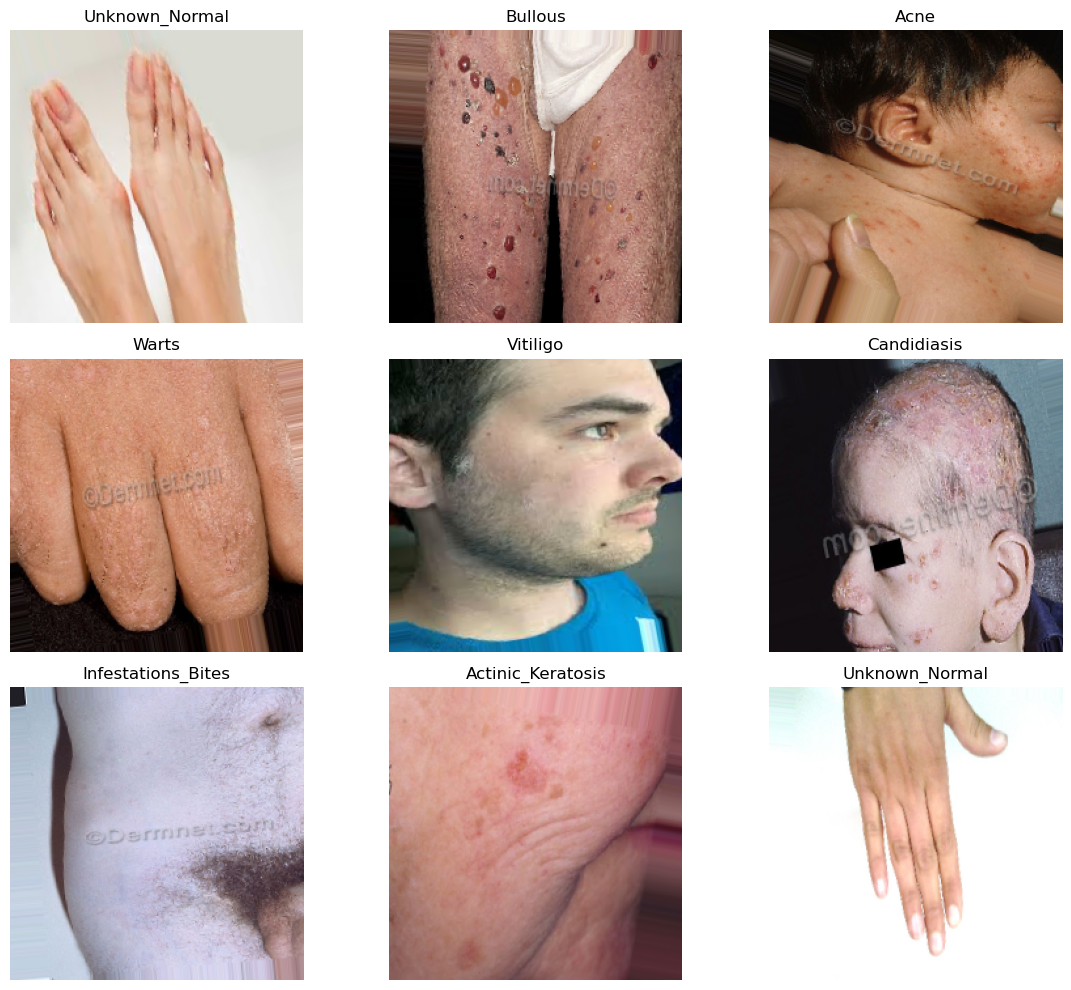

In [21]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(12, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])

    class_index = labels[i].argmax()
    class_name = list(train_generator.class_indices.keys())[class_index]

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

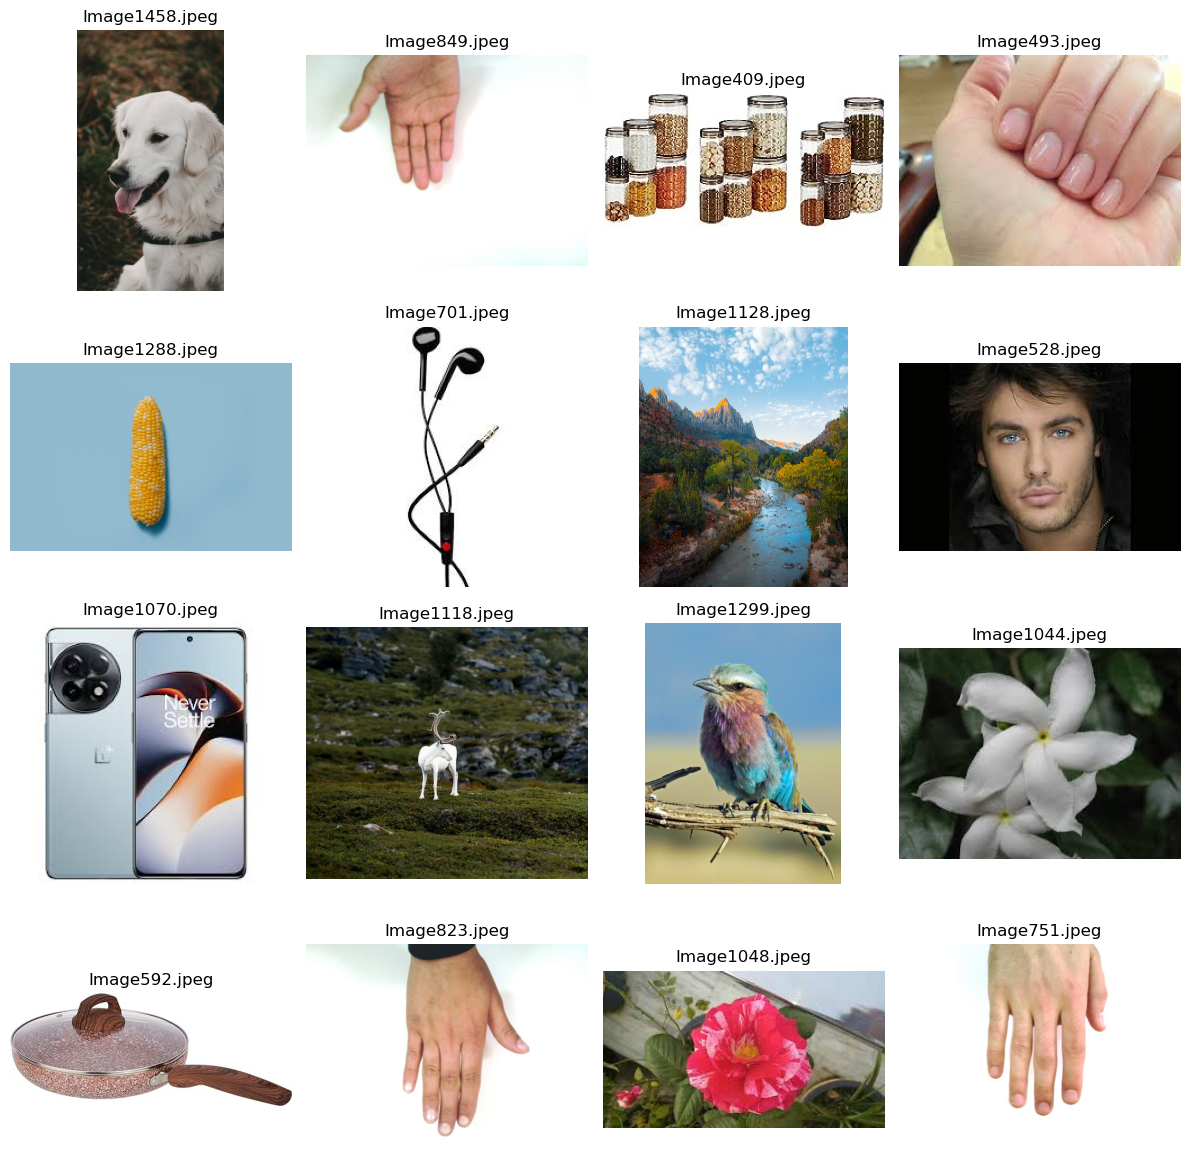

In [22]:
import matplotlib.pyplot as plt

unknown_path = os.path.join(train_path, "Unknown_Normal")

files = [
    f for f in os.listdir(unknown_path)
    if os.path.isfile(os.path.join(unknown_path, f))
]

sample_files = random.sample(files, min(16, len(files)))

plt.figure(figsize=(12, 12))

for i, filename in enumerate(sample_files):
    file_path = os.path.join(unknown_path, filename)

    try:
        img = Image.open(file_path)
        plt.subplot(4, 4, i + 1)
        plt.imshow(img)
        plt.title(filename[:15])
        plt.axis("off")
    except Exception:
        pass

plt.tight_layout()
plt.show()

In [23]:
train_unknown_path = os.path.join(train_path, "Unknown_Normal")
test_unknown_path = os.path.join(test_path, "Unknown_Normal")

print("Training Unknown_Normal images:",
      len([f for f in os.listdir(train_unknown_path)
           if os.path.isfile(os.path.join(train_unknown_path, f))]))

print("Testing Unknown_Normal images:",
      len([f for f in os.listdir(test_unknown_path)
           if os.path.isfile(os.path.join(test_unknown_path, f))]))

Training Unknown_Normal images: 1651
Testing Unknown_Normal images: 189


In [24]:
classes_to_use = [
    'Acne',
    'Actinic_Keratosis',
    'Benign_tumors',
    'Bullous',
    'Candidiasis',
    'DrugEruption',
    'Eczema',
    'Infestations_Bites',
    'Lichen',
    'Lupus',
    'Moles',
    'Psoriasis',
    'Rosacea',
    'Seborrh_Keratoses',
    'SkinCancer',
    'Sun_Sunlight_Damage',
    'Tinea',
    'Vascular_Tumors',
    'Vasculitis',
    'Vitiligo',
    'Warts'
]

print("Number of classes being used:", len(classes_to_use))

Number of classes being used: 21


In [25]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    classes=classes_to_use,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    classes=classes_to_use,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nNumber of classes:", len(train_generator.class_indices))
print("\nClass indices:")
print(train_generator.class_indices)

Found 12247 images belonging to 21 classes.
Found 1357 images belonging to 21 classes.

Number of classes: 21

Class indices:
{'Acne': 0, 'Actinic_Keratosis': 1, 'Benign_tumors': 2, 'Bullous': 3, 'Candidiasis': 4, 'DrugEruption': 5, 'Eczema': 6, 'Infestations_Bites': 7, 'Lichen': 8, 'Lupus': 9, 'Moles': 10, 'Psoriasis': 11, 'Rosacea': 12, 'Seborrh_Keratoses': 13, 'SkinCancer': 14, 'Sun_Sunlight_Damage': 15, 'Tinea': 16, 'Vascular_Tumors': 17, 'Vasculitis': 18, 'Vitiligo': 19, 'Warts': 20}


In [26]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Number of disease classes
num_classes = len(train_generator.class_indices)

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
base_model.trainable = False

# Create our model
model = Sequential([
    base_model,
    
    GlobalAveragePooling2D(),
    
    Dense(128, activation='relu'),
    Dropout(0.5),
    
    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 21)                  │           2,709 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,424,661 (9.25 MB)

 Trainable params: 166,677 (651.08 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [27]:
#Train the model

In [28]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=3
)

print("Training completed successfully!")

Epoch 1/3
 57/383 ━━━━━━━━━━━━━━━━━━━━ 12:37 2s/step - accuracy: 0.0995 - loss: 3.1348

KeyboardInterrupt: 

In [ ]:
model.save("skin_disease_mobilenetv2_stage1.keras")

print("Model saved successfully!")

In [30]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print("MobileNetV2 fine-tuning enabled!")

MobileNetV2 fine-tuning enabled!


In [31]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model recompiled for fine-tuning!")

Model recompiled for fine-tuning!


In [32]:
fine_tune_history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=3
)

print("Fine-tuning completed successfully!")

Epoch 1/3
383/383 ━━━━━━━━━━━━━━━━━━━━ 2086s 5s/step - accuracy: 0.2288 - loss: 2.5906 - val_accuracy: 0.3545 - val_loss: 2.1184
Epoch 2/3
383/383 ━━━━━━━━━━━━━━━━━━━━ 1531s 4s/step - accuracy: 0.2812 - loss: 2.3377 - val_accuracy: 0.3604 - val_loss: 2.1093
Epoch 3/3
383/383 ━━━━━━━━━━━━━━━━━━━━ 1213s 3s/step - accuracy: 0.3015 - loss: 2.2696 - val_accuracy: 0.3648 - val_loss: 2.0994
Fine-tuning completed successfully!


In [33]:
model.save("skin_disease_mobilenetv2_finetuned.keras")

print("Fine-tuned model saved successfully!")

Fine-tuned model saved successfully!


In [30]:
from tensorflow.keras.models import load_model

model = load_model("skin_disease_mobilenetv2_finetuned.keras")

print("Fine-tuned model loaded successfully!")

Fine-tuned model loaded successfully!


In [31]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

43/43 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.3648 - loss: 2.0994
Test Loss: 2.0994105339050293
Test Accuracy: 0.36477524042129517


In [32]:
fine_tune_history_2 = model.fit(
    train_generator,
    validation_data=test_generator,
    initial_epoch=3,
    epochs=4
)

print("Epoch 4 completed successfully!")

Epoch 4/4
383/383 ━━━━━━━━━━━━━━━━━━━━ 2459s 6s/step - accuracy: 0.3116 - loss: 2.2371 - val_accuracy: 0.3714 - val_loss: 2.0915
Epoch 4 completed successfully!


In [33]:
fine_tune_history_3 = model.fit(
    train_generator,
    validation_data=test_generator,
    initial_epoch=4,
    epochs=5
)

print("Epoch 5 completed successfully!")

Epoch 5/5
383/383 ━━━━━━━━━━━━━━━━━━━━ 658s 2s/step - accuracy: 0.3252 - loss: 2.2047 - val_accuracy: 0.3685 - val_loss: 2.0860
Epoch 5 completed successfully!


In [28]:
from collections import Counter

class_counts = Counter(train_generator.classes)

print("Training images per class:")
print("-" * 40)

for class_name, class_index in sorted(
    train_generator.class_indices.items(),
    key=lambda x: x[1]
):
    print(f"{class_name:25s}: {class_counts[class_index]}")

Training images per class:
----------------------------------------
Acne                     : 593
Actinic_Keratosis        : 748
Benign_tumors            : 1093
Bullous                  : 504
Candidiasis              : 248
DrugEruption             : 547
Eczema                   : 1010
Infestations_Bites       : 524
Lichen                   : 553
Lupus                    : 311
Moles                    : 361
Psoriasis                : 820
Rosacea                  : 254
Seborrh_Keratoses        : 455
SkinCancer               : 693
Sun_Sunlight_Damage      : 312
Tinea                    : 923
Vascular_Tumors          : 543
Vasculitis               : 461
Vitiligo                 : 714
Warts                    : 580


43/43 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step


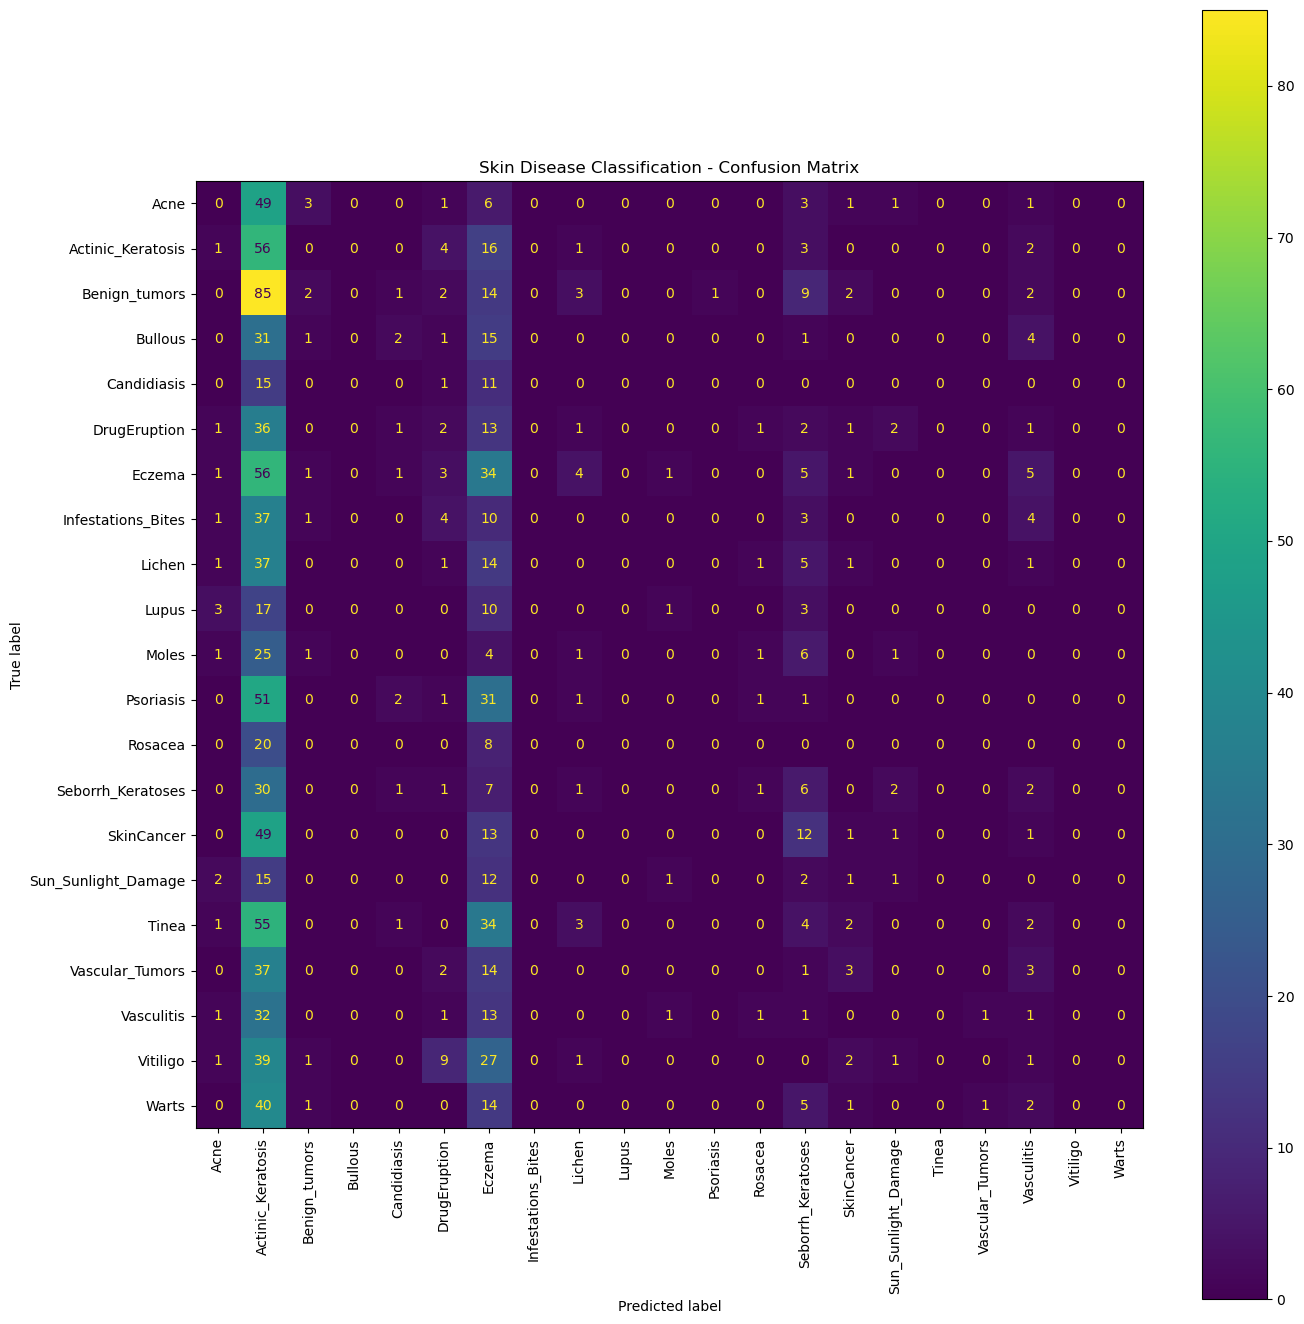

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions from the current test generator
test_generator.reset()

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Class names in the correct order
class_names = list(test_generator.class_indices.keys())

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(14, 14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=90,
    values_format='d',
    ax=plt.gca()
)

plt.title("Skin Disease Classification - Confusion Matrix")
plt.tight_layout()
plt.show()

In [30]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_indices = train_generator.class_indices

classes = np.array(list(class_indices.values()))
y_train = train_generator.classes

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, class_weights_array)
)

print("Class weights:")
for class_name, class_index in class_indices.items():
    print(f"{class_name:25s}: {class_weights[class_index]:.3f}")

Class weights:
Acne                     : 0.983
Actinic_Keratosis        : 0.780
Benign_tumors            : 0.534
Bullous                  : 1.157
Candidiasis              : 2.352
DrugEruption             : 1.066
Eczema                   : 0.577
Infestations_Bites       : 1.113
Lichen                   : 1.055
Lupus                    : 1.875
Moles                    : 1.615
Psoriasis                : 0.711
Rosacea                  : 2.296
Seborrh_Keratoses        : 1.282
SkinCancer               : 0.842
Sun_Sunlight_Damage      : 1.869
Tinea                    : 0.632
Vascular_Tumors          : 1.074
Vasculitis               : 1.265
Vitiligo                 : 0.817
Warts                    : 1.006


In [36]:
import numpy as np
from sklearn.metrics import classification_report

# Reset test generator
test_generator.reset()

# Get predictions
predictions = model.predict(test_generator)

# Convert probabilities to class indices
y_pred = np.argmax(predictions, axis=1)

# Get true class labels
y_true = test_generator.classes

# Get class names
class_names = list(test_generator.class_indices.keys())

# Classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

43/43 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step
                     precision    recall  f1-score   support

               Acne       0.39      0.65      0.49        65
  Actinic_Keratosis       0.39      0.41      0.40        83
      Benign_tumors       0.35      0.64      0.45       121
            Bullous       0.52      0.20      0.29        55
        Candidiasis       0.00      0.00      0.00        27
       DrugEruption       0.44      0.34      0.39        61
             Eczema       0.25      0.66      0.36       112
 Infestations_Bites       0.38      0.18      0.25        60
             Lichen       0.44      0.07      0.11        61
              Lupus       0.20      0.03      0.05        34
              Moles       0.31      0.25      0.28        40
          Psoriasis       0.24      0.33      0.27        88
            Rosacea       0.46      0.43      0.44        28
  Seborrh_Keratoses       0.39      0.27      0.32        51
         SkinCancer       0.47      0.23     

In [37]:
#2nd Method

In [38]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_v2 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen_v2 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [39]:
train_generator_v2 = train_datagen_v2.flow_from_directory(
    train_path,
    classes=classes_to_use,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator_v2 = test_datagen_v2.flow_from_directory(
    test_path,
    classes=classes_to_use,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 12247 images belonging to 21 classes.
Found 1357 images belonging to 21 classes.


In [40]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

num_classes = len(train_generator_v2.class_indices)

base_model_v2 = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers initially
base_model_v2.trainable = False

model_v2 = Sequential([
    base_model_v2,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 21)                  │           2,709 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,424,661 (9.25 MB)

 Trainable params: 166,677 (651.08 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [41]:
from tensorflow.keras.optimizers import Adam

model_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model V2 compiled successfully!")

Model V2 compiled successfully!


In [ ]:
history_v2 = model_v2.fit(
    train_generator_v2,
    validation_data=test_generator_v2,
    epochs=3
)

print("Model V2 training completed successfully!")

Epoch 1/3
 33/383 ━━━━━━━━━━━━━━━━━━━━ 11:19 2s/step - accuracy: 0.0886 - loss: 3.3333

In [1]:
#1st method again

In [2]:
fine_tune_history_2 = model.fit(
    train_generator,
    validation_data=test_generator,
    initial_epoch=3,
    epochs=4
)

print("Epoch 4 completed successfully!")

NameError: name 'model' is not defined